In [1]:
import numpy as np
import matplotlib.pyplot as plt
import uproot
import pandas as pd
import dunestyle.matplotlib as dunestyle
from tamaker import TAMaker
from presets import COLLECTION_CENTRAL, COLLECTION_LATERAL


DUNE plot style enabled


# Load  data

In [2]:
def load_data(file_path, file_key, print_keys = False):
    with uproot.open(file_path) as file:

        #Print out keys, just to see what's there 
        if print_keys:
            for key in file.keys():
                print(key)

        tree = file[file_key]
        
        # Convert  TTree to pandas df
        df = tree.arrays( library="pd")


        return df 


# triggerAna/event_summary : gives total number of events, total visible energy in the full detector for the event (used for trigger efficiency plots)
# triggerAna/mcneutrinos & triggerAna/mctruths: contains mctruth information about the generator (GENIE in this case). (Unfortunately, because some people felt strongly about the 
# analyser dumping a single collection to a single TTree, it means we have to combine neutrino information from two TTrees to get the full picture )
# triggerAna/mcparticles : contains geant4 output 
# triggerAna/simides : contains simIDE information--> millions per event, and as this is already summarised in event_summary & TP bt_* fields, it's better not to use it unless necessary, as it can crash your kernel. 
# triggerAna/TriggerPrimitives : TPG output  

filepath = './data/prodgenie_nu_dune10kt_1x2x6__trg_mc_2025a_tpg__tpg_dune10kt_1x2x6__triggerAna__v10_12_01d01__triggerana_dune10kt_1x2x6__v10_12_01d01__ntuple__NU_prod-pass2_v2_20251126T000804_f7.root'

mctruth = load_data(filepath, 'triggerAna/mctruths', print_keys=True)
mcnu = load_data(filepath, 'triggerAna/mcneutrinos')
evsum =  load_data(filepath, 'triggerAna/event_summary')
tps =  load_data(filepath, 'triggerAna/TriggerPrimitives/tpmakerTPCsimpleThr__TPGen') 

triggerAna;1
triggerAna/TriggerPrimitives;1
triggerAna/TriggerPrimitives/tpmakerTPCsimpleThr__TPGen;1
triggerAna/TriggerPrimitives/tpmakerTPCabsRS__TPGen;1
triggerAna/simides;1
triggerAna/mcparticles;1
triggerAna/info;6
triggerAna/info;5
triggerAna/info;4
triggerAna/info;3
triggerAna/info;2
triggerAna/info;1
triggerAna/mctruths;1
triggerAna/mcneutrinos;1
triggerAna/event_summary;1


### mctruth & mcnu df

In [3]:
#mcneutrino TTree is only useful because it contains detailed information about the interaction 
display(mcnu) #should be strictly one entry per event. 

#useful columns: ccnc; tells you if this was a neutral or charged current interaction, mode tells you the interaction type (see below)
ccnc_map = {'cc': 0, 'nc':1}; mode_map = {'QE': 0, 'RES': 1, 'DIS': 2, 'Coh. Prod': 3, '?': 5, 'MEC' : 10}

,event,run,subrun,block_id,generator_name,nupdg,leptonpdg,ccnc,mode,interactionType,target,hitnuc,hitquark,w,x,y,qsqr,pt,theta
0,43881,8525,0,0,,14,13,0,0,1001,1000180400,2112,0,1.018814,0.645917,0.139345,0.285327,0.170220,0.342092
1,43882,8525,0,0,generator,14,14,1,1,1008,1000180400,2112,0,1.472968,0.308686,0.317743,0.575147,0.314855,0.295096
2,43883,8525,0,0,generator,14,13,0,2,1091,1000180400,2112,1,1.807594,0.274833,0.631241,0.904210,0.279849,0.567229
3,43884,8525,0,0,generator,14,13,0,0,1001,1000180400,2112,0,1.202865,0.797539,0.634192,2.226901,0.236404,1.107471
4,43885,8525,0,0,generator,14,13,0,2,1091,1000180400,2112,1,2.125776,0.494136,0.402644,3.553020,0.958811,0.256910
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5995,88486,8525,0,0,generator,14,13,0,1,1005,1000180400,2112,0,1.221455,0.587443,0.367757,0.869130,0.216006,0.553066
5996,88487,8525,0,0,generator,14,13,0,2,1091,1000180400,2112,1,1.496752,0.314986,0.376032,0.624764,0.283209,0.356514
5997,88488,8525,0,0,generator,14,13,0,2,1091,1000180400,2112,1,4.926736,0.181854,0.542337,5.199293,2.830490,0.119983
5998,88489,8525,0,0,generator,14,13,0,1,1003,1000180400,2212,0,1.146326,0.867597,0.700573,2.834004,0.250343,1.336944


In [4]:
display(mctruth)
#primary neutrino has truth_track_id == 0 
#useful columns : energy (in GeV); x,y,z give interaction vertex; pdg gives neutrino flavour; px,py,pz &p can be used to calculate neutrino direction w.r.t APA plane

,event,run,subrun,block_id,truth_track_id,pdg,generator_name,status_code,x,y,z,px,py,pz,p,energy,kinetic_energy,process
0,43881,8525,0,0,0,14,generator,0,66.095692,407.372335,255.392488,7.346562e-07,0.170220,1.679568,1.688171,1.688171,1.688171,primary
1,43881,8525,0,0,1,1000180400,generator,0,66.095692,407.372335,255.392488,0.000000e+00,0.000000,0.000000,0.000000,37.215526,0.000000,primary
2,43881,8525,0,0,2,2112,generator,11,66.095692,407.372335,255.392488,-1.201751e-01,0.050092,-0.116395,NaN,0.906627,-0.032938,primary
3,43881,8525,0,0,3,1000180390,generator,2,66.095692,407.372335,255.392488,1.190126e-01,-0.050767,0.117498,1.244362,36.307160,0.021330,primary
4,43881,8525,0,0,4,22,generator,1,66.095692,407.372335,255.392488,1.162470e-03,0.000675,-0.001103,0.001739,0.001739,0.001739,primary
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94292,88490,8525,0,0,19,-211,generator,1,-326.361656,364.669871,-2.081356,-1.597247e-01,0.443075,1.510253,1.581990,1.588135,1.448565,primary
94293,88490,8525,0,0,20,111,generator,1,-326.361656,364.669871,-2.081356,-3.567114e-01,0.896518,1.632280,1.896135,1.900933,1.765956,primary
94294,88490,8525,0,0,21,2112,generator,1,-326.361656,364.669871,-2.081356,-1.939177e-01,0.552596,2.457280,2.526104,2.695178,1.755612,primary
94295,88490,8525,0,0,22,111,generator,1,-326.361656,364.669871,-2.081356,1.484174e-01,0.145357,0.736505,0.765243,0.777056,0.642079,primary


In [5]:

#let's just extract the useful columns from mcnu TTree and combine both into a single df to make life easier. 
nu = pd.merge(mctruth[mctruth.truth_track_id == 0], mcnu[['event', 'run', 'subrun', 'ccnc', 'mode']], on=["event", "run", "subrun"])

display(nu) #now this should contain all the information about your neutrino: direction, vertex, energy, interaction type etc. 

,event,run,subrun,block_id,truth_track_id,pdg,generator_name,status_code,x,y,z,px,py,pz,p,energy,kinetic_energy,process,ccnc,mode
0,43881,8525,0,0,0,14,generator,0,66.095692,407.372335,255.392488,7.346562e-07,0.170220,1.679568,1.688171,1.688171,1.688171,primary,0,0
1,43882,8525,0,0,0,14,generator,0,17.728111,78.538466,751.502159,6.327929e-07,0.314855,3.106774,3.122688,3.122688,3.122688,primary,1,1
2,43883,8525,0,0,0,14,generator,0,-57.113406,-89.019236,552.950145,-1.662970e-06,0.279849,2.761396,2.775540,2.775540,2.775540,primary,0,2
3,43884,8525,0,0,0,14,generator,0,278.436866,186.599448,979.532310,6.125482e-06,0.236404,2.332660,2.344609,2.344609,2.344609,primary,0,0
4,43885,8525,0,0,0,14,generator,0,-237.445676,-571.787859,783.125917,-1.106572e-05,0.958811,9.461368,9.509827,9.509827,9.509827,primary,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5995,88486,8525,0,0,0,14,generator,0,-22.035091,-416.534890,573.809084,-2.738797e-07,0.216006,2.131480,2.142397,2.142397,2.142397,primary,0,1
5996,88487,8525,0,0,0,14,generator,0,-371.431805,-229.553440,1064.458154,-1.010829e-05,0.283209,2.794617,2.808931,2.808931,2.808931,primary,0,2
5997,88488,8525,0,0,0,14,generator,0,207.521600,-355.306487,958.951940,4.470539e-05,2.830490,27.930265,28.073322,28.073322,28.073322,primary,0,2
5998,88489,8525,0,0,0,14,generator,0,81.581775,-352.989738,399.380414,3.457196e-06,0.250343,2.470317,2.482970,2.482970,2.482970,primary,0,1


### event_summary

In [6]:
#ROP 0,1 == U, V induction planes. ROP 3,4 == collection planes from side A and side B of the APA. 
#To get the total visible energy in the collection planes for the entire detector just add up the ROPs 

evsum['visible_energy'] = evsum.tot_visible_energy_rop3 + evsum.tot_visible_energy_rop2 #Note: here the visible energy in measured in MeV
display(evsum)

,event,run,subrun,tot_visible_energy_rop0,tot_visible_energy_rop1,tot_visible_energy_rop2,tot_visible_energy_rop3,tot_numelectrons_rop0,tot_numelectrons_rop1,tot_numelectrons_rop2,tot_numelectrons_rop3,visible_energy
0,43881,8525,0,1549.219804,1549.217196,54.967092,1494.271674,3.845607e+07,3.845616e+07,5.205010e+05,3.793605e+07,1549.238766
1,43882,8525,0,653.055995,653.050560,28.270580,624.740031,1.048515e+07,1.048514e+07,5.238284e+05,9.961272e+06,653.010611
2,43883,8525,0,2328.199776,2328.135243,2026.550615,301.726321,5.637992e+07,5.638007e+07,5.065635e+07,5.723885e+06,2328.276935
3,43884,8525,0,1966.342750,1966.213223,0.000000,1966.379113,4.206652e+07,4.206646e+07,0.000000e+00,4.206730e+07,1966.379113
4,43885,8525,0,4471.071231,4471.025136,4443.323077,27.842067,1.057572e+08,1.057576e+08,1.054380e+08,3.221690e+05,4471.165144
...,...,...,...,...,...,...,...,...,...,...,...,...
5995,88486,8525,0,1684.525196,1684.474839,1330.145799,354.425407,4.020210e+07,4.020208e+07,3.493837e+07,5.264116e+06,1684.571206
5996,88487,8525,0,814.523514,814.519855,814.608092,0.000000,1.919457e+07,1.919453e+07,1.919540e+07,0.000000e+00,814.608092
5997,88488,8525,0,13116.037030,13116.409426,328.209203,12789.007537,2.632110e+08,2.632109e+08,5.772695e+06,2.574419e+08,13117.216740
5998,88489,8525,0,1877.321444,1877.372107,430.988708,1446.311325,3.999362e+07,3.999358e+07,1.137489e+07,2.861887e+07,1877.300032


## TPs and TAs 

In [7]:
#pre-select only collection TPs and apply some cuts from the get-go to speed things up. 
tps_raw = tps[(tps.readout_view==2) &(tps.samples_over_threshold>8)]

In [8]:
#Apply the TAMaker ( just load up your ta/tp dfs, if you have already completed this step)
maker = TAMaker(**COLLECTION_CENTRAL)
tas, tps = maker.run(tps_raw)

DBSCAN inspect: 100%|██████████| 9917/9917 [00:04<00:00, 2074.41it/s]


In [9]:
#  lateral efficiencies 

makerl = TAMaker(**COLLECTION_LATERAL)
tas_l, tps_l = makerl.run(tps_raw)

DBSCAN inspect: 100%|██████████| 13215/13215 [00:03<00:00, 4090.64it/s]


,event,apa_id,rop,window_start,flag,TA_id,total_window_energy,TP_count,n_clusters,mean_cluster_energy,total_cluster_energy,max_cluster_energy,ch_mean,t_mean,ch_std,t_std,ch_wmean,t_wmean,ch_wstd,t_wstd
7,43883,4,2,0,2,11,4750310,438,-1,-1.000000,-1,-1,12151.821918,531.977169,85.564872,241.093039,12166.520582,466.258536,96.756625,233.502479
8,43883,4,2,1000,2,12,896702,154,-1,-1.000000,-1,-1,12226.694805,1182.642857,43.495533,99.226141,12227.484734,1183.340276,42.343000,95.725651
9,43883,6,2,0,2,15,364813,52,-1,-1.000000,-1,-1,16998.403846,104.211538,48.958876,100.727992,16992.253689,76.586755,31.422564,55.840467
10,43883,6,3,0,2,17,674376,71,-1,-1.000000,-1,-1,17550.126761,335.380282,71.291295,216.042404,17543.717641,332.325396,64.684125,189.697857
11,43883,6,3,1000,2,18,117235,22,-1,-1.000000,-1,-1,17774.136364,1554.090909,54.206923,178.003296,17768.221854,1545.406184,44.133242,163.105345
12,43883,7,2,1000,2,20,2019475,356,-1,-1.000000,-1,-1,19697.500000,1681.983146,102.767942,139.086788,19714.811770,1699.411364,108.483862,138.876712
26232,43883,5,2,1000,2,14,33699,7,1,33699.000000,33699,33699,14876.000000,1384.142857,2.000000,4.453845,14875.848749,1383.803229,2.019564,4.509214
26233,43883,6,2,1000,2,16,24072,4,1,24072.000000,24072,24072,16961.500000,1294.500000,1.118034,3.500000,16961.421776,1293.891991,0.878804,3.363781
26234,43883,8,3,1000,0,22,46812,8,3,8210.333333,24631,10158,22641.500000,1332.000000,0.500000,0.000000,22641.543414,1332.000000,0.498112,0.000000


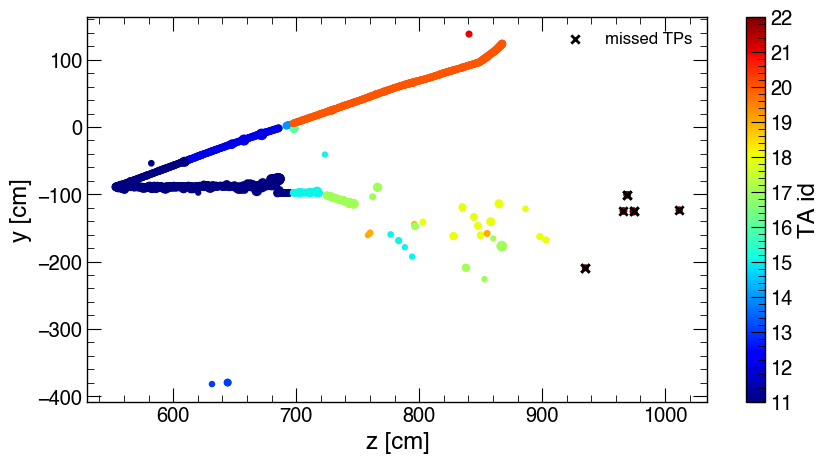

In [10]:
#Let's plot an event display
event =43883 
x = tps[(tps.event == event) &(tps.bt_edep>0)]
display(tas[tas.event==event]) #here you can see which TAs got accepted and which got rejected 

plt.figure(figsize=(10,5))
plt.scatter(x.bt_z, x.bt_y, c=x.TA_id, s=x.samples_over_threshold, cmap='jet')
plt.xlabel("z [cm]")
plt.ylabel("y [cm]")
plt.colorbar(ticks=np.arange(x.TA_id.min(), x.TA_id.max()+1)).set_label("TA id")

failed_TAs = tas[(tas.event==event) & (tas.flag==0)].TA_id.unique()

plt.scatter(x[x.TA_id.isin(failed_TAs)].bt_z, x[x.TA_id.isin(failed_TAs)].bt_y, marker='x', label ='missed TPs')
plt.legend()

# Efficiency curves

In [11]:
#add visible energy column to the tas 
tas_l =  pd.merge(tas_l, evsum[['event','visible_energy']], on=["event"]) 
tas_c =  pd.merge(tas, evsum[['event','visible_energy']], on=["event"]) 
    

/var/folders/1s/mfxsnwp9275ft3r75z4zs6c80000gn/T/ipykernel_7305/2909170065.py:7: RuntimeWarning: overflow encountered in exp
  return L / (1 + np.exp(-k * (x - x0))) + b


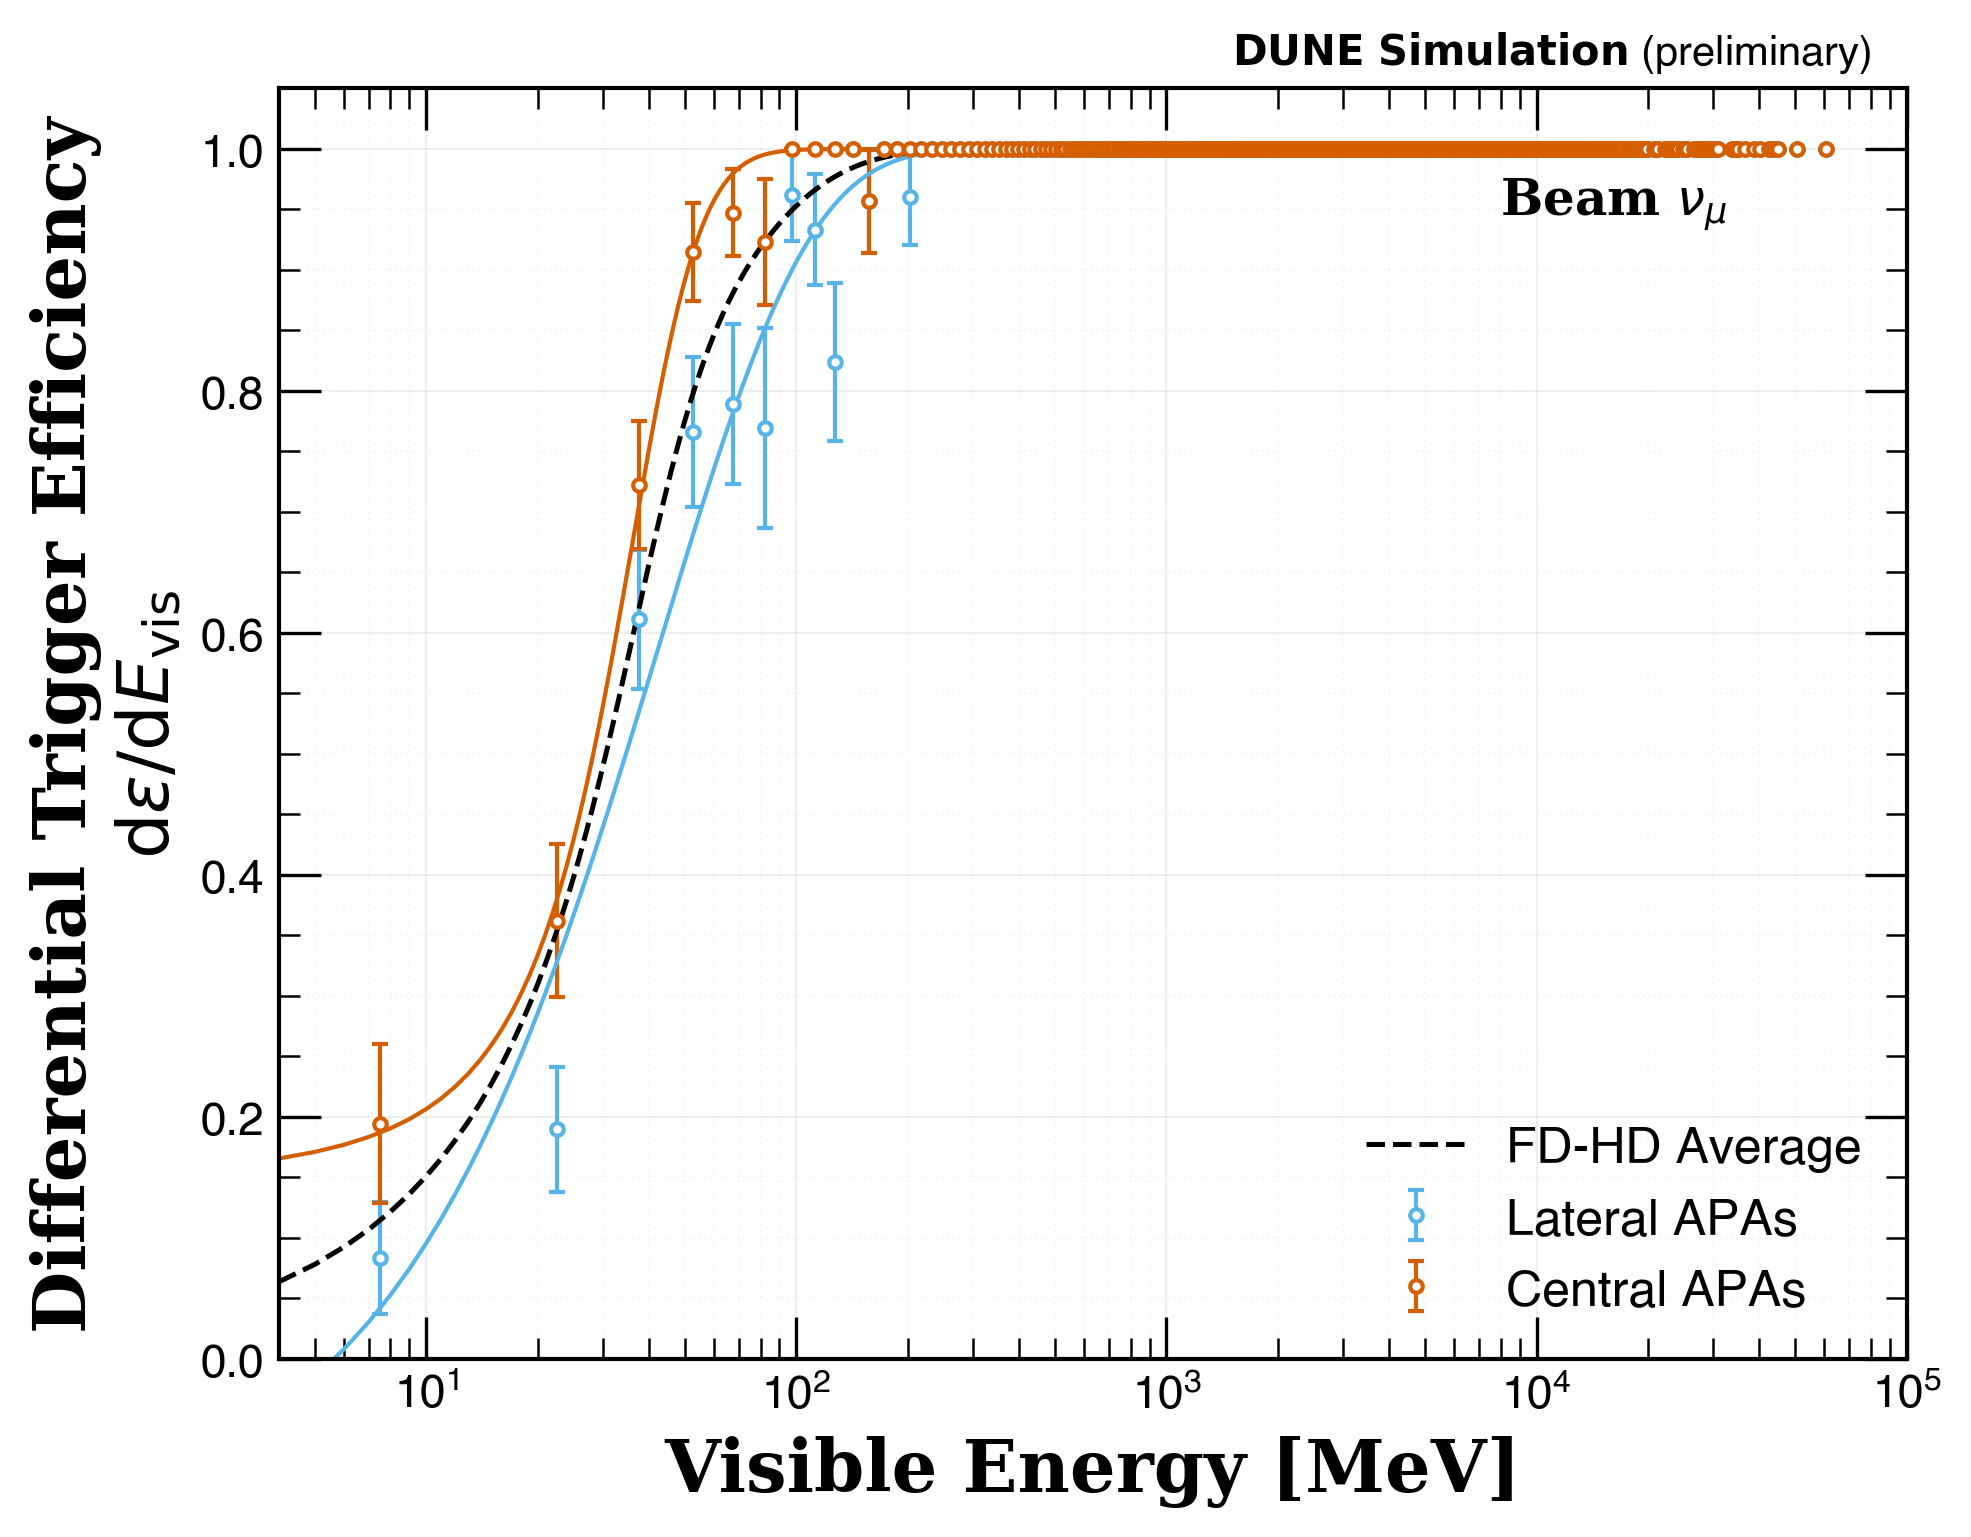

In [ ]:
from scipy.optimize import curve_fit

colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
cl, cc = colors[2], colors[1]

def sigmoid(x, L, x0, k, b):
    return L / (1 + np.exp(-k * (x - x0))) + b

def compute_sensitivity(df, dx, max_eng=1e5):
    energies = np.arange(0, max_eng, dx)
    bin_centers = energies[:-1] + dx / 2
    sensitivity, errors = [], []
    for start in energies[:-1]:
        upper = start + dx

        #total number of events in this energy slice 
        events = df[(df.visible_energy >= start) & (df.visible_energy < upper)] 
        #number of triggered events 
        accepted = events[events.flag == 2]
        
        n, k = events.event.nunique(), accepted.event.nunique()
        if n > 0:
            sens = k / n
            err = np.sqrt(sens * (1 - sens) / n)
        else:
            sens, err = np.nan, 0
        sensitivity.append(sens)
        errors.append(err)
    return np.array(bin_centers), np.array(sensitivity), np.array(errors)

data_lat, data_cent = [tas_l], [tas_c]
fig, ax = plt.subplots(figsize=(7,5.5), dpi=300)
lines_for_legend = []

for idx in range(len(data_lat)):
    bin_lat, sens_lat, err_lat = compute_sensitivity(data_lat[idx], dx=15)
    bin_cent, sens_cent, err_cent = compute_sensitivity(data_cent[idx], dx=15)

    mask_lat, mask_cent = ~np.isnan(sens_lat), ~np.isnan(sens_cent)

    try:
        popt_lat, _ = curve_fit(sigmoid, bin_lat[mask_lat], sens_lat[mask_lat], p0=[1,10,1,0], maxfev=1000)
    except:
        popt_lat = [1,10,1,0]
    try:
        popt_cent, _ = curve_fit(sigmoid, bin_cent[mask_cent], sens_cent[mask_cent], p0=[1,10,1,0], maxfev=1000)
    except:
        popt_cent = [1,10,1,0]

    x_fit = np.linspace(4, 1000, 1000)
    y_fit_lat = sigmoid(x_fit, *popt_lat)
    y_fit_cent = sigmoid(x_fit, *popt_cent)
    y_fit_mean = (y_fit_lat + y_fit_cent) / 2

    ax.errorbar(bin_lat, sens_lat, yerr=err_lat, fmt='o', capsize=2, markersize=3, markerfacecolor='white', elinewidth=1, color=cl, label='Lateral APAs')
    ax.errorbar(bin_cent, sens_cent, yerr=err_cent, fmt='o', capsize=2, markersize=3, markerfacecolor='white', elinewidth=1, color=cc, label='Central APAs')
    line_cent, = ax.plot(x_fit, y_fit_cent, color=cc, linewidth=1)
    line_lat, = ax.plot(x_fit, y_fit_lat, color=cl, linewidth=1)
    line_mean, = ax.plot(x_fit, y_fit_mean, color='black', linewidth=1.2, linestyle='--', label='FD-HD Average')

    if idx == 0:
        lines_for_legend = [line_cent, line_lat, line_mean]

ax.tick_params(axis='both', which='both', direction='in', top=True, right=True, labelsize=11)
ax.set_ylim(0, 1.05)
ax.set_xlim(4, 1e5)
ax.grid(True, which='major', linestyle='-', linewidth=0.5, alpha=0.2)
ax.grid(True, which='minor', linestyle=':', alpha=0.1)
ax.set_xscale('log')
ax.set_xlabel("Visible Energy [MeV]", fontweight='bold', family='serif')
ax.set_ylabel(r"Differential Trigger Efficiency" + "\n" + r"$\mathrm{d}\varepsilon / \mathrm{d}E_\mathrm{vis}$", fontweight='bold', family='serif')
ax.legend(frameon=False, loc='lower right')
ax.text(1.5e3, 1.07, r'$\bf{DUNE\ Simulation}$ (preliminary)')
ax.minorticks_on()
ax.text(0.75, 0.90, r"Beam $\nu_{\mu}$", transform=ax.transAxes, fontsize=12, fontweight='bold', family='serif')
plt.show()

In [14]:
#Merge the trigger dfs with the rest of the neutrino interactions 
tas_l = pd.merge(tas_l, nu[['event','mode', 'ccnc','x','y','z']], on="event")
tas_c = pd.merge(tas_c, nu[['event','mode', 'ccnc','x','y','z']], on="event")

In [16]:
from rich.console import Console
from rich.table import Table

trigl =  tas_l
trigc =  tas_c

console = Console()

counts = nu['ccnc'].value_counts()

table = Table(show_header=True, width =50, title=r"beam neutrinos")
for name in counts.index:
    label = next(k for k, v in ccnc_map.items() if v == name)
    table.add_column(label, justify="center")

row = [f"{(count / counts.sum()) * 100:.2g} %" for count in counts.values]
table.add_row(*row)

console.print(table)


counts = nu['mode'].value_counts()

table = Table(show_header=True, width =100, title='beam neutrinos')
for name in counts.index:
    label = next(k for k, v in mode_map.items() if v == name)
    table.add_column(label, justify="center")
row = [ f"{(count / counts.sum()) * 100:.2g} %"  for count in counts.values]
table.add_row(*row)

console.print(table)


print("Percentage of events triggered 'out of the box' ")
for idx , type_label in enumerate(ccnc_map):    

    print(f"Triggered {type_label} events (lateral): " , (trigl[(trigl.ccnc==idx) & (trigl.flag==2)].event.nunique()/trigl[(trigl.ccnc==idx) ].event.nunique() * 100))
    print(f"Triggered {type_label} events (central): " , (trigc[(trigc.ccnc==idx) & (trigc.flag==2)].event.nunique()/trigc[(trigc.ccnc==idx) ].event.nunique() * 100) )

print("Total (L): ",  int(trigl[(trigl.flag==2)].event.nunique()/trigl.event.nunique() * 100), ', (C):',  int(trigc[(trigc.flag==2)].event.nunique()/trigc.event.nunique() * 100))

print("\n" + "Percentage of events triggered on in the active volume ")

trigl_ac = trigl[(trigl.x.abs() <360) & (trigl.y.abs() < 600) & (trigl.z>0) & (trigl.z < 1380) & (trigl.visible_energy> 0)]
trigc_ac = trigc[(trigc.x.abs() <360) & (trigc.y.abs() < 600) & (trigc.z>0) & (trigc.z < 1380) & (trigc.visible_energy> 0)]

for idx , type_label in enumerate(ccnc_map):    

    print(f"Triggered {type_label} events (lateral): " , (trigl_ac[(trigl_ac.ccnc==idx) & (trigl_ac.flag==2)].event.nunique()/trigl_ac[(trigl_ac.ccnc==idx) ].event.nunique() * 100))
    print(f"Triggered {type_label} events (central): " , (trigc_ac[(trigc_ac.ccnc==idx) & (trigc_ac.flag==2)].event.nunique()/trigc_ac[(trigc_ac.ccnc==idx) ].event.nunique() * 100) )

print("Total (L): ",  trigl_ac[(trigl_ac.flag==2)].event.nunique()/trigl_ac.event.nunique() * 100, ', (C):',  trigc_ac[(trigc_ac.flag==2)].event.nunique()/trigc_ac.event.nunique() * 100, 
        ", 10 kT", 0.5*(trigl_ac[(trigl_ac.flag==2)].event.nunique()/trigl_ac.event.nunique() +trigc_ac[(trigc_ac.flag==2)].event.nunique()/trigc_ac.event.nunique() ) * 100)


# Fraction of events which produced less that 100 MeV of visible energy in the active volume 
# trig_beam_nue_lat[ (trig_beam_nue_lat.visible_energy < 100) &(trig_beam_nue_lat.event.isin(fv_event) &(trig_beam_nue_lat.ccnc==1))].event.nunique()/trig_beam_nue_lat[(trig_beam_nue_lat.event.isin(fv_event)) ].event.nunique() *100

                  beam neutrinos                  
┏━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┓
┃           cc           ┃          nc           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━┩
│          76 %          │         24 %          │
└────────────────────────┴───────────────────────┘

                                           beam neutrinos                                           
┏━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┓
┃     DIS     ┃     RES     ┃     QE      ┃     MEC      ┃      Coh. Prod       ┃        ?         ┃
┡━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━┩
│    37 %     │    36 %     │    22 %     │    4.2 %     │        0.48 %        │     0.017 %      │
└─────────────┴─────────────┴─────────────┴──────────────┴──────────────────────┴──────────────────┘

Percentage of events triggered 'out of the box' 
Triggered cc events (lateral):  98.97641299510458
Triggered cc events (central):  99.17668001780152
Triggered nc events (lateral):  92.90369297610427
Triggered nc events (central):  95.80014482259233
Total (L):  97 , (C): 98

Percentage of events triggered on in the active volume 
Triggered cc events (lateral):  100.0
Triggered cc events (central):  100.0
Triggered nc events (lateral):  94.46280991735537
Triggered nc events (central):  97.02479338842976
Total (L):  98.70180197636117 , (C): 99.30246076341794 , 10 kT 99.00213136988955


In [ ]:
#now if you want to plot efficiency as a function of energy for e.g. only nc events, you can select tas_c[tas_c.ccnc==1] etc.
# you can also plot efficiency vs. neutrino angle, drigt position etc. 
# you can also select low energy events (Triggered or not) and create event displays to understand why they did or did not result in a trigger. 